<a href="https://colab.research.google.com/github/Rollethm/MultipleQWwithTails/blob/main/WeightedPathQuantumWalk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

重み付きのpathグラフ上量子探索

*   各頂点にa,b,cの重み付き有向辺
*   外部流入は元のグラフの頂点倍
*   distance-regular graph



In [ ]:
# @title <font color='green'>日本語対応</font>
!apt-get -y install fonts-ipafont-gothic
!pip install japanize-matplotlib
import japanize_matplotlib
import matplotlib.pyplot as plt

# 場合によっては必要
plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-mincho all 00303-21ubuntu1 [4,724 kB]
Fetched 8,237 kB in 1s (8,019 kB/s)
Selecting previously unselected package fonts-ipafont-gothic.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-ipafont-gothic_00303-21ubuntu1_all.deb ...
Unpacking fonts-ipafont-gothic (00303-21ubuntu1) ...
Selecting previously unselected package fonts-ipaf


#<font color = 'green' >LibratyAndClass </font>

In [ ]:
# @title <font color='green'>Liblary</font>
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math

In [ ]:
# @title <font color='green'>クラス: WeightedPathQuantumWalkWithTailsMountVer(Googleマウント版)</font>
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

class WeightedPathQuantumWalkWithTailsMountVer:
    """
    重み付きパスグラフ（セルフループ付き）でのコイン型量子ウォーク（外部tailを含む）。
    - 状態空間は「各アークに対応する振幅ベクトル」。
    - 外部流入（tail）の重み計算時には、元のグラフの頂点数(N)が掛け合わせられます。
    """

    def __init__(self, N: int, A: list, B: list, C: list):
        """
        N: グラフの頂点数
        A: 右からの重みリスト a_v (長さN, A[v]は v+1 -> v の重み)
        B: セルフループの重みリスト b_v (長さN, B[v]は v -> v の重み)
        C: 左からの重みリスト c_v (長さN, C[v]は v-1 -> v の重み)
        """
        self.N_nodes = N
        self.A = A
        self.B = B
        self.C = C

        # 有向グラフの構築
        self.G = nx.DiGraph()
        self.G.add_nodes_from(range(N))

        # セルフループ付きのパスグラフの辺を追加
        for v in range(N):
            # 左からの辺 (v-1 -> v)
            if v > 0:
                self.G.add_edge(v-1, v, type='forward')
            # セルフループ (v -> v)
            # B[v] の値が 0 でない場合のみ、セルフループの辺を追加
            if self.B[v] != 0:
                self.G.add_edge(v, v, type='self')
            # 右からの辺 (v+1 -> v)
            if v < N - 1:
                self.G.add_edge(v+1, v, type='backward')

        # アーク（ordered list）とインデックスの対応
        self.arcs = list(self.G.edges())
        self.arc_index = {arc: i for i, arc in enumerate(self.arcs)}
        self.n_arcs = len(self.arcs)

        # アークごとのコンダクタンス m(a)
        self.m_arc = np.ones(self.n_arcs, dtype=float)

        # 頂点ごとの入辺インデックスリスト
        self.in_arcs_of = {v: [] for v in self.G.nodes()}
        for i, (u, v) in enumerate(self.arcs):
            self.in_arcs_of[v].append(i)

        # 行列・ベクトルの初期化
        self.Coin = np.eye(self.n_arcs, dtype=complex)
        self.S = np.eye(self.n_arcs, dtype=complex)
        self.U = np.eye(self.n_arcs, dtype=complex)
        self.psi = np.zeros(self.n_arcs, dtype=complex)
        self.rho = np.zeros(self.n_arcs, dtype=complex)

        self.history = list()
        self.history_arc = list()
        self.history_prob = list()

    # ---------- コンダクタンスの設定 ----------
    def set_conductances(self, marked_vertices: set, epsilon: float, external_arcs: set):
        if external_arcs is None:
            external_arcs = set()

        for i, (u, v) in enumerate(self.arcs):
            # 辺の方向に基づいて重みを取得
            weight = 1.0
            if u == v - 1:
                weight = self.C[v]  # 左からの重み c_v
            elif u == v:
                weight = self.B[v]  # セルフループの重み b_v
            elif u == v + 1:
                weight = self.A[v]  # 右からの重み a_v

            # マークされた頂点に入る辺の処理
            if v in marked_vertices:
                self.m_arc[i] = float(epsilon) * weight
            else:
                self.m_arc[i] = 1.0 * weight

    # ---------- コイン行列の構築 ----------
    def build_coin(self, marked_vertices: set, epsilon: float, external_arcs: set):
        n = self.n_arcs
        Coin = np.eye(n, dtype=complex)

        for v, in_idxs in self.in_arcs_of.items():
            d = len(in_idxs)
            if d == 0:
                continue

            Mv = sum(self.m_arc[i] for i in in_idxs)

            # 外部からの流入（tail）は、元のグラフの頂点数倍(self.N_nodes)を考慮する
            if v in external_arcs:
                if v in marked_vertices:
                    Mv += 1.0
                else:
                    Mv += float(epsilon)

            if Mv == 0:
                Cx = np.eye(d, dtype=complex)
            else:
                px = np.array([np.sqrt(self.m_arc[i] / Mv) for i in in_idxs], dtype=complex).reshape((d, 1))
                Cx = 2.0 * (px @ px.conj().T) - np.eye(d, dtype=complex)

            for ii, i_arc in enumerate(in_idxs):
                for jj, j_arc in enumerate(in_idxs):
                    Coin[i_arc, j_arc] = Cx[ii, jj]

        self.Coin = Coin
        self.U = self.S @ self.Coin

    # ---------- シフト行列の構築 ----------
    def build_shift(self):
        S = np.zeros((self.n_arcs, self.n_arcs), dtype=complex)

        for i, (u, v) in enumerate(self.arcs):
            rev = (v, u) # 逆辺
            j = self.arc_index.get(rev, None)
            if j is None:
                # 逆向きアークが存在しない場合は自己ループ
                S[i, i] = 1.0
            else:
                S[j, i] = 1.0

        self.S = S
        self.U = self.S @ self.Coin

    # ---------- 外部流入 rho のセット ----------
    def set_rho(self, marked_vertices: set, epsilon: float, external_arcs: set, N_origin_node: set):
        rho = np.zeros(self.n_arcs, dtype=complex)

        for i, (u, v) in enumerate(self.arcs):
            if u in external_arcs:
                u_in_idxs = self.in_arcs_of[u]
                Mv = sum(self.m_arc[j] for j in u_in_idxs)

                # tailの重みを頂点数倍して振幅を計算
                if u in marked_vertices:
                    Mv += 1.0
                    p_tail = np.sqrt(1.0 * N_origin_node[u] / Mv)
                else:
                    Mv += float(epsilon)
                    p_tail = np.sqrt(float(epsilon) * N_origin_node[u] / Mv)

                # u から出ていく辺への振幅
                rev=(v,u)
                j=self.arc_index.get(rev,None)
                if j is None:
                    print("rho の構築で逆辺が見つかりませんでした")
                else:
                    p_j = np.sqrt(self.m_arc[j] / Mv)
                rho[i] = 2.0 * p_tail * p_j

        self.rho = rho

    # ---------- 初期化・時間発展 ----------
    def set_initial_state(self, psi0: np.ndarray):
        psi0 = np.asarray(psi0, dtype=complex)
        if psi0.shape != (self.n_arcs,):
            raise ValueError("psi0 の長さがアーク数と一致しません")
        self.psi = psi0.copy()

    def step(self, z: complex):
        self.psi = z * self.U @ self.psi + self.rho

    def run(self, steps: int, epsilon: float, z: complex, N_origin_node: set, print_value=False):
        self.history = []
        self.history_arc = []
        for i in range(steps):
            self.step(z=z)
            self.history.append(self.vertex_probabilities(epsilon, step=i, steps=steps, N_origin_node=N_origin_node))
            self.history_arc.append(self.arc_probabilities(epsilon, step=i, steps=steps, print_value=print_value, N_origin_node=N_origin_node))
            self.history_prob.append(self.v_probabilities(epsilon, step=i, steps=steps, N_origin_node=N_origin_node))

    # ---------- 観測 ----------
    def vertex_probabilities(self, epsilon: float, step: int, steps: int, N_origin_node: set):
        probs = {v: 0.0 for v in self.G.nodes()}
        for v, in_idxs in self.in_arcs_of.items():
            if epsilon > 0:
                probs[v] = float(epsilon) * float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0
            elif epsilon == 0:
                probs[v] = float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0

            if step == steps - 1:
                print(f"Pv_∞({v:2d}) = {probs[v]:2.4f}")
        return probs

    def v_probabilities(self, epsilon: float, step: int, steps: int, N_origin_node: set):
        probs_v = {v: 0.0 for v in self.G.nodes()}
        sum_probs = 0.0
        for v, in_idxs in self.in_arcs_of.items():
            if epsilon > 0:
                probs_v[v] = float(epsilon) * float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0
            elif epsilon == 0:
                probs_v[v] = float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0

        for v, in_idxs in self.in_arcs_of.items():
            sum_probs += probs_v[v] * N_origin_node[v]
        #print(f"Sum of Probabilityies : {sum_probs}")
        if sum_probs > 0:
            for v in probs_v:
                probs_v[v] /= sum_probs
                if step == steps-1:
                    print(f"Pv_∞({v:2d}) = {probs_v[v]:2.4f}")
        return probs_v

    def arc_probabilities(self, epsilon: float, step: int, steps: int, N_origin_node: set, print_value=False):
        prbs_arc = {idx: 0.0 for idx in self.arc_index.values()}
        for (u,v), idxs in self.arc_index.items():
            if epsilon > 0:
                prbs_arc[idxs] = float(epsilon) * float((np.abs(self.psi[idxs])**2))
            elif epsilon == 0:
                prbs_arc[idxs] = float((np.abs(self.psi[idxs])**2))

            denom = 0
            if u == v - 1:
                denom = N_origin_node[v] * self.C[v]
                if denom != 0:
                    prbs_arc[idxs] = prbs_arc[idxs] / (N_origin_node[v] * self.C[v])  # 左からの重み c_v
                else:
                    prbs_arc[idxs] = 0.0

            elif u == v:
                denom = N_origin_node[v] * self.B[v]
                if denom != 0:
                    prbs_arc[idxs] = prbs_arc[idxs] / (N_origin_node[v] * self.B[v])  # セルフループの重み b_v
                else:
                    prbs_arc[idxs] = 0.0

            elif u == v + 1:
                denom = N_origin_node[v] * self.A[v]
                if denom != 0:
                    prbs_arc[idxs] = prbs_arc[idxs] / (N_origin_node[v] * self.A[v])
                else:
                    prbs_arc[idxs] = 0.0

            if print_value and step == steps - 1:
                print(f"Pa_∞({idxs:2d}) = {prbs_arc[idxs]:2.4f}")
        return prbs_arc

    # ---------- プロット・ユーティリティ ----------
    def plot_undirected_graph(self):
        # パスグラフを見やすくするために直線上の座標を指定
        pos = {v: (v, 0) for v in self.G.nodes()}
        nx.draw(self.G.to_undirected(), pos, with_labels=True, node_color='lightblue')
        plt.title("Undirected Graph Structure")
        plt.show()

    def plot_arcs(self):
        pos = {v: (v, 0) for v in self.G.nodes()}
        fig, ax = plt.subplots(figsize=(8, 4))
        nx.draw_networkx_nodes(self.G, pos, ax=ax, node_color='lightblue')
        nx.draw_networkx_labels(self.G, pos, ax=ax)
        nx.draw_networkx_edges(self.G, pos, ax=ax, edgelist=self.arcs, connectionstyle="arc3, rad=0.3")
        plt.title("Directed Arcs")
        plt.axis('off')
        plt.show()

    def plot_weighted_graph(self):
        pos = {i: (i, 0) for i in range(self.N_nodes)} # 一列に配置

        fig, ax = plt.subplots(figsize=(12, 4))

        # ノードの描画
        nx.draw_networkx_nodes(self.G, pos, node_size=600, node_color='white', edgecolors='black', ax=ax)
        nx.draw_networkx_labels(self.G, pos, font_size=12, ax=ax)

        # エッジの描画（種類ごとにカーブを変える）
        for (u, v), idx in self.arc_index.items():
            if u == v - 1: # 左から右へ（上側にカーブ,c_v）
                arc = "arc3,rad=0.3"
                color = "blue"
                label_pos = 0.3
                label=f"{self.C[v]}"
            elif u == v + 1: # 右から左へ（下側にカーブ,a_v）
                arc = "arc3,rad=0.3"
                color = "red"
                label_pos = 0.3
                label=f"{self.A[v]}"
            else: # セルフループ（真上に円を描く）
                arc = "arc3,rad=2.0"
                color = "green"
                label_pos = 0.5
                label=f"{self.B[v]}"

            nx.draw_networkx_edges(self.G, pos, edgelist=[(u, v)], connectionstyle=arc, edge_color=color, arrowsize=15, ax=ax)

            # 簡易的な重みラベルの表示（位置を微調整）
            x_mid = (pos[u][0] + pos[v][0]) / 2
            y_mid = (pos[u][1] + pos[v][1]) / 2

            offset = -0.05 if u == v - 1 else 0.16
            if u == v + 1: offset = 0.05

            ax.text(x_mid, y_mid + offset, label, color=color, fontsize=10, ha='center', fontweight='bold')

        plt.title("Weighted Path Graph (Blue: $c_v$, Red: $a_v$, Green: $b_v$)", fontsize=14)
        plt.axis('off')
        #plt.show()
        return fig

    def plot_vertex_probs(self, steps: int, marked_vertices: set):
        list_steps = list(range(steps))
        all_vertices = list(self.G.nodes())
        normal_vertices = [v for v in all_vertices if v not in marked_vertices]

        # ---------- 通常頂点のProbability ----------
        cols = 3
        rows = max(1, int((len(normal_vertices) + cols - 1) // cols))
        fig1, axes1 = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows))
        if rows * cols == 1:
            axes1 = [axes1]
        else:
            axes1 = axes1.flatten()

        for ax, v in zip(axes1, normal_vertices):
            probs_v = [h.get(v, 0) for h in self.history]
            ax.plot(list_steps, probs_v, marker='.')
            ax.set_title(f"node_{v}")
            ax.set_xlabel("Step")
            ax.set_ylabel("R_Probability")
            ax.grid(True)

        fig1.suptitle("Normal Vertices R_Probability Evolution", fontsize=14)
        fig1.tight_layout(rect=[0, 0, 1, 0.97])

        figs=[fig1]

        # ---------- マークした頂点のProbability ----------
        if len(marked_vertices) > 0:
            fig2, axes2 = plt.subplots(len(marked_vertices), 1, figsize=(6, 3 * len(marked_vertices)))
            if len(marked_vertices) == 1:
                axes2 = [axes2]

            for ax, v in zip(axes2, marked_vertices):
                probs_v = [h.get(v, 0) for h in self.history]
                ax.plot(list_steps, probs_v, color='red')
                ax.set_title(f"node_{v} (Marked)")
                ax.set_xlabel("Step")
                ax.set_ylabel("R_Probability")
                ax.grid(True)

            fig2.suptitle("Marked Vertices R_Probability Evolution", fontsize=14)
            fig2.tight_layout(rect=[0, 0, 1, 0.97])
            figs.append(fig2)
        return figs
        #plt.show()

    def plot_v_probs(self, steps: int, marked_vertices: set):
        list_steps = list(range(steps))
        all_vertices = list(self.G.nodes())
        normal_vertices = [v for v in all_vertices if v not in marked_vertices]

        # ---------- 通常頂点のProbability ----------
        cols = 3
        rows = max(1, int((len(normal_vertices) + cols - 1) // cols))
        fig1, axes1 = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows))
        if rows * cols == 1:
            axes1 = [axes1]
        else:
            axes1 = axes1.flatten()

        for ax, v in zip(axes1, normal_vertices):
            probs_v = [h.get(v, 0) for h in self.history_prob]
            ax.plot(list_steps, probs_v, marker='.')
            ax.set_title(f"node_{v}")
            ax.set_xlabel("Step")
            ax.set_ylabel("Probability")
            ax.grid(True)

        fig1.suptitle("Normal Vertices Probability Evolution", fontsize=14)
        fig1.tight_layout(rect=[0, 0, 1, 0.97])

        figs=[fig1]

        # ---------- マークした頂点のProbability ----------
        if len(marked_vertices) > 0:
            fig2, axes2 = plt.subplots(len(marked_vertices), 1, figsize=(6, 3 * len(marked_vertices)))
            if len(marked_vertices) == 1:
                axes2 = [axes2]

            for ax, v in zip(axes2, marked_vertices):
                probs_v = [h.get(v, 0) for h in self.history_prob]
                ax.plot(list_steps, probs_v, color='red')
                ax.set_title(f"node_{v} (Marked)")
                ax.set_xlabel("Step")
                ax.set_ylabel("Probability")
                ax.grid(True)

            fig2.suptitle("Marked Vertices Probability Evolution", fontsize=14)
            fig2.tight_layout(rect=[0, 0, 1, 0.97])
            figs.append(fig2)
        return figs

    def plot_arc_probs(self, steps: int, marked_vertices: set):
        list_steps = list(range(steps))
        cols = 3
        rows = int((self.n_arcs + cols - 1) // cols)

        fig3, axes3 = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows))
        axes3 = axes3.flatten()

        for ax, ((i, j), idx) in zip(axes3, self.arc_index.items()):
            probs_a = [h.get(idx, 0) for h in self.history_arc]
            if j in marked_vertices:
                ax.plot(list_steps, probs_a, color='red', marker='.')
            elif i in marked_vertices:
                ax.plot(list_steps, probs_a, color='green', marker='.')
            else:
                ax.plot(list_steps, probs_a, marker='.')

            ax.set_title(f"R_Probability of arc_({i},{j})")
            ax.set_xlabel("Step")
            ax.set_ylabel("R_Probability")
            ax.grid(True)

        fig3.suptitle("Arc R_Probability Evolution", fontsize=14)
        fig3.tight_layout(rect=[0, 0, 1, 0.97])
        return fig3
        #plt.show()

    def get_eigenpairs(self, vctBool: bool):
        eigenvalues, eigenvectors = np.linalg.eig(self.U)
        for i in range(len(eigenvalues)):
            eigenvectors[i] = eigenvectors[i] / np.linalg.norm(eigenvectors[i])
            if vctBool:
                print(f"value: {eigenvalues[i]}")
                print(f"vector: ")
                print(eigenvectors[i])
            else:
                print(f"value: {eigenvalues[i]}")

In [ ]:
# @title <font color = 'green'>クラス: WeightedPathQuantumWalkWithTails </font>
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

class WeightedPathQuantumWalkWithTails:
    """
    重み付きパスグラフ（セルフループ付き）でのコイン型量子ウォーク（外部tailを含む）。
    - 状態空間は「各アークに対応する振幅ベクトル」。
    - 外部流入（tail）の重み計算時には、元のグラフの頂点数(N)が掛け合わせられます。
    """

    def __init__(self, N: int, A: list, B: list, C: list):
        """
        N: グラフの頂点数
        A: 右からの重みリスト a_v (長さN, A[v]は v+1 -> v の重み)
        B: セルフループの重みリスト b_v (長さN, B[v]は v -> v の重み)
        C: 左からの重みリスト c_v (長さN, C[v]は v-1 -> v の重み)
        """
        self.N_nodes = N
        self.A = A
        self.B = B
        self.C = C

        # 有向グラフの構築
        self.G = nx.DiGraph()
        self.G.add_nodes_from(range(N))

        # セルフループ付きのパスグラフの辺を追加
        for v in range(N):
            # 左からの辺 (v-1 -> v)
            if v > 0:
                self.G.add_edge(v-1, v, type='forward')
            # セルフループ (v -> v)
            # B[v] の値が 0 でない場合のみ、セルフループの辺を追加
            if self.B[v] != 0:
                self.G.add_edge(v, v, type='self')
            # 右からの辺 (v+1 -> v)
            if v < N - 1:
                self.G.add_edge(v+1, v, type='backward')

        # アーク（ordered list）とインデックスの対応
        self.arcs = list(self.G.edges())
        self.arc_index = {arc: i for i, arc in enumerate(self.arcs)}
        self.n_arcs = len(self.arcs)

        # アークごとのコンダクタンス m(a)
        self.m_arc = np.ones(self.n_arcs, dtype=float)

        # 頂点ごとの入辺インデックスリスト
        self.in_arcs_of = {v: [] for v in self.G.nodes()}
        for i, (u, v) in enumerate(self.arcs):
            self.in_arcs_of[v].append(i)

        # 行列・ベクトルの初期化
        self.Coin = np.eye(self.n_arcs, dtype=complex)
        self.S = np.eye(self.n_arcs, dtype=complex)
        self.U = np.eye(self.n_arcs, dtype=complex)
        self.psi = np.zeros(self.n_arcs, dtype=complex)
        self.rho = np.zeros(self.n_arcs, dtype=complex)

        self.history = list()
        self.history_arc = list()
        self.history_prob = list()

    # ---------- コンダクタンスの設定 ----------
    def set_conductances(self, marked_vertices: set, epsilon: float, external_arcs: set):
        if external_arcs is None:
            external_arcs = set()

        for i, (u, v) in enumerate(self.arcs):
            # 辺の方向に基づいて重みを取得
            weight = 1.0
            if u == v - 1:
                weight = self.C[v]  # 左からの重み c_v
            elif u == v:
                weight = self.B[v]  # セルフループの重み b_v
            elif u == v + 1:
                weight = self.A[v]  # 右からの重み a_v

            # マークされた頂点に入る辺の処理
            if v in marked_vertices:
                self.m_arc[i] = float(epsilon) * weight
            else:
                self.m_arc[i] = 1.0 * weight

    # ---------- コイン行列の構築 ----------
    def build_coin(self, marked_vertices: set, epsilon: float, external_arcs: set):
        n = self.n_arcs
        Coin = np.eye(n, dtype=complex)

        for v, in_idxs in self.in_arcs_of.items():
            d = len(in_idxs)
            if d == 0:
                continue

            Mv = sum(self.m_arc[i] for i in in_idxs)

            # 外部からの流入（tail）は、元のグラフの頂点数倍(self.N_nodes)を考慮する
            if v in external_arcs:
                if v in marked_vertices:
                    Mv += 1.0
                else:
                    Mv += float(epsilon)

            if Mv == 0:
                Cx = np.eye(d, dtype=complex)
            else:
                px = np.array([np.sqrt(self.m_arc[i] / Mv) for i in in_idxs], dtype=complex).reshape((d, 1))
                Cx = 2.0 * (px @ px.conj().T) - np.eye(d, dtype=complex)

            for ii, i_arc in enumerate(in_idxs):
                for jj, j_arc in enumerate(in_idxs):
                    Coin[i_arc, j_arc] = Cx[ii, jj]

        self.Coin = Coin
        self.U = self.S @ self.Coin

    # ---------- シフト行列の構築 ----------
    def build_shift(self):
        S = np.zeros((self.n_arcs, self.n_arcs), dtype=complex)

        for i, (u, v) in enumerate(self.arcs):
            rev = (v, u) # 逆辺
            j = self.arc_index.get(rev, None)
            if j is None:
                # 逆向きアークが存在しない場合は自己ループ
                S[i, i] = 1.0
            else:
                S[j, i] = 1.0

        self.S = S
        self.U = self.S @ self.Coin

    # ---------- 外部流入 rho のセット ----------
    def set_rho(self, marked_vertices: set, epsilon: float, external_arcs: set, N_origin_node: set):
        rho = np.zeros(self.n_arcs, dtype=complex)

        for i, (u, v) in enumerate(self.arcs):
            if u in external_arcs:
                u_in_idxs = self.in_arcs_of[u]
                Mv = sum(self.m_arc[j] for j in u_in_idxs)

                # tailの重みを頂点数倍して振幅を計算
                if u in marked_vertices:
                    Mv += 1.0
                    p_tail = np.sqrt(1.0 * N_origin_node[u] / Mv)
                else:
                    Mv += float(epsilon)
                    p_tail = np.sqrt(float(epsilon) * N_origin_node[u] / Mv)

                # u から出ていく辺への振幅
                rev=(v,u)
                j=self.arc_index.get(rev,None)
                if j is None:
                    print("rho の構築で逆辺が見つかりませんでした")
                else:
                    p_j = np.sqrt(self.m_arc[j] / Mv)
                rho[i] = 2.0 * p_tail * p_j

        self.rho = rho

    # ---------- 初期化・時間発展 ----------
    def set_initial_state(self, psi0: np.ndarray):
        psi0 = np.asarray(psi0, dtype=complex)
        if psi0.shape != (self.n_arcs,):
            raise ValueError("psi0 の長さがアーク数と一致しません")
        self.psi = psi0.copy()

    def step(self, z: complex):
        self.psi = z * self.U @ self.psi + self.rho

    def run(self, steps: int, epsilon: float, z: complex, N_origin_node: set, print_value=False):
        self.history = []
        self.history_arc = []
        for i in range(steps):
            self.step(z=z)
            self.history.append(self.vertex_probabilities(epsilon, step=i, steps=steps, N_origin_node=N_origin_node))
            self.history_arc.append(self.arc_probabilities(epsilon, step=i, steps=steps, print_value=print_value, N_origin_node=N_origin_node))
            self.history_prob.append(self.v_probabilities(epsilon, step=i, steps=steps, N_origin_node=N_origin_node))

    # ---------- 観測 ----------
    def vertex_probabilities(self, epsilon: float, step: int, steps: int, N_origin_node: set):
        probs = {v: 0.0 for v in self.G.nodes()}
        for v, in_idxs in self.in_arcs_of.items():
            if epsilon > 0:
                probs[v] = float(epsilon) * float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0
            elif epsilon == 0:
                probs[v] = float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0

            if step == steps - 1:
                print(f"RPv_∞({v:2d}) = {probs[v]:2.4f}")
        return probs

    def v_probabilities(self, epsilon: float, step: int, steps: int, N_origin_node: set):
        probs_v = {v: 0.0 for v in self.G.nodes()}
        sum_probs = 0.0
        for v, in_idxs in self.in_arcs_of.items():
            if epsilon > 0:
                probs_v[v] = float(epsilon) * float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0
            elif epsilon == 0:
                probs_v[v] = float(np.sum(np.abs(self.psi[in_idxs])**2)) / N_origin_node[v] if in_idxs else 0.0

        for v, in_idxs in self.in_arcs_of.items():
            sum_probs += probs_v[v] * N_origin_node[v]
        #print(f"Sum of Probabilityies : {sum_probs}")
        if sum_probs > 0:
            for v in probs_v:
                probs_v[v] /= sum_probs
                if step == steps-1:
                    print(f"Pv_∞({v:2d}) = {probs_v[v]:2.4f}")
        return probs_v

    def arc_probabilities(self, epsilon: float, step: int, steps: int, N_origin_node: set, print_value=False):
        prbs_arc = {idx: 0.0 for idx in self.arc_index.values()}
        for (u,v), idxs in self.arc_index.items():
            if epsilon > 0:
                prbs_arc[idxs] = float(epsilon) * float((np.abs(self.psi[idxs])**2))
            elif epsilon == 0:
                prbs_arc[idxs] = float((np.abs(self.psi[idxs])**2))

            denom = 0
            if u == v - 1:
                denom = N_origin_node[v] * self.C[v]
                if denom != 0:
                    prbs_arc[idxs] = prbs_arc[idxs] / (N_origin_node[v] * self.C[v])  # 左からの重み c_v
                else:
                    prbs_arc[idxs] = 0.0

            elif u == v:
                denom = N_origin_node[v] * self.B[v]
                if denom != 0:
                    prbs_arc[idxs] = prbs_arc[idxs] / (N_origin_node[v] * self.B[v])  # セルフループの重み b_v
                else:
                    prbs_arc[idxs] = 0.0

            elif u == v + 1:
                denom = N_origin_node[v] * self.A[v]
                if denom != 0:
                    prbs_arc[idxs] = prbs_arc[idxs] / (N_origin_node[v] * self.A[v])
                else:
                    prbs_arc[idxs] = 0.0

            if print_value and step == steps - 1:
                print(f"Pa_∞({idxs:2d}) = {prbs_arc[idxs]:2.4f}")
        return prbs_arc

    # ---------- プロット・ユーティリティ ----------
    def plot_undirected_graph(self):
        # パスグラフを見やすくするために直線上の座標を指定
        pos = {v: (v, 0) for v in self.G.nodes()}
        nx.draw(self.G.to_undirected(), pos, with_labels=True, node_color='lightblue')
        plt.title("Undirected Graph Structure")
        plt.show()

    def plot_arcs(self):
        pos = {v: (v, 0) for v in self.G.nodes()}
        fig, ax = plt.subplots(figsize=(8, 4))
        nx.draw_networkx_nodes(self.G, pos, ax=ax, node_color='lightblue')
        nx.draw_networkx_labels(self.G, pos, ax=ax)
        nx.draw_networkx_edges(self.G, pos, ax=ax, edgelist=self.arcs, connectionstyle="arc3, rad=0.3")
        plt.title("Directed Arcs")
        plt.axis('off')
        plt.show()

    def plot_weighted_graph(self):
        pos = {i: (i, 0) for i in range(self.N_nodes)} # 一列に配置

        fig, ax = plt.subplots(figsize=(12, 4))

        # ノードの描画
        nx.draw_networkx_nodes(self.G, pos, node_size=600, node_color='white', edgecolors='black', ax=ax)
        nx.draw_networkx_labels(self.G, pos, font_size=12, ax=ax)

        # エッジの描画（種類ごとにカーブを変える）
        for (u, v), idx in self.arc_index.items():
            if u == v - 1: # 左から右へ（上側にカーブ,c_v）
                arc = "arc3,rad=0.3"
                color = "blue"
                label_pos = 0.3
                label=f"{self.C[v]}"
            elif u == v + 1: # 右から左へ（下側にカーブ,a_v）
                arc = "arc3,rad=0.3"
                color = "red"
                label_pos = 0.3
                label=f"{self.A[v]}"
            else: # セルフループ（真上に円を描く）
                arc = "arc3,rad=2.0"
                color = "green"
                label_pos = 0.5
                label=f"{self.B[v]}"

            nx.draw_networkx_edges(self.G, pos, edgelist=[(u, v)], connectionstyle=arc, edge_color=color, arrowsize=15, ax=ax)

            # 簡易的な重みラベルの表示（位置を微調整）
            x_mid = (pos[u][0] + pos[v][0]) / 2
            y_mid = (pos[u][1] + pos[v][1]) / 2

            offset = -0.05 if u == v - 1 else 0.16
            if u == v + 1: offset = 0.05

            ax.text(x_mid, y_mid + offset, label, color=color, fontsize=10, ha='center', fontweight='bold')

        plt.title("Weighted Path Graph (Blue: $c_v$, Red: $a_v$, Green: $b_v$)", fontsize=14)
        plt.axis('off')
        plt.show()
        #return fig

    def plot_vertex_probs(self, steps: int, marked_vertices: set):
        list_steps = list(range(steps))
        all_vertices = list(self.G.nodes())
        normal_vertices = [v for v in all_vertices if v not in marked_vertices]

        # ---------- 通常頂点のProbability ----------
        cols = 3
        rows = max(1, int((len(normal_vertices) + cols - 1) // cols))
        fig1, axes1 = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows))
        if rows * cols == 1:
            axes1 = [axes1]
        else:
            axes1 = axes1.flatten()

        for ax, v in zip(axes1, normal_vertices):
            probs_v = [h.get(v, 0) for h in self.history]
            ax.plot(list_steps, probs_v, marker='.')
            ax.set_title(f"node_{v}")
            ax.set_xlabel("Step")
            ax.set_ylabel("R_Probability")
            ax.grid(True)

        fig1.suptitle("Normal Vertices R_Probability Evolution", fontsize=14)
        fig1.tight_layout(rect=[0, 0, 1, 0.97])

        #figs=[fig1]

        # ---------- マークした頂点のProbability ----------
        if len(marked_vertices) > 0:
            fig2, axes2 = plt.subplots(len(marked_vertices), 1, figsize=(6, 3 * len(marked_vertices)))
            if len(marked_vertices) == 1:
                axes2 = [axes2]

            for ax, v in zip(axes2, marked_vertices):
                probs_v = [h.get(v, 0) for h in self.history]
                ax.plot(list_steps, probs_v, color='red')
                ax.set_title(f"node_{v} (Marked)")
                ax.set_xlabel("Step")
                ax.set_ylabel("R_Probability")
                ax.grid(True)

            fig2.suptitle("Marked Vertices R_Probability Evolution", fontsize=14)
            fig2.tight_layout(rect=[0, 0, 1, 0.97])
            #figs.append(fig2)
        #return figs
        plt.show()


    def plot_v_probs(self, steps: int, marked_vertices: set):
        list_steps = list(range(steps))
        all_vertices = list(self.G.nodes())
        normal_vertices = [v for v in all_vertices if v not in marked_vertices]

        # ---------- 通常頂点のProbability ----------
        cols = 3
        rows = max(1, int((len(normal_vertices) + cols - 1) // cols))
        fig1, axes1 = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows))
        if rows * cols == 1:
            axes1 = [axes1]
        else:
            axes1 = axes1.flatten()

        for ax, v in zip(axes1, normal_vertices):
            probs_v = [h.get(v, 0) for h in self.history_prob]
            ax.plot(list_steps, probs_v, marker='.')
            ax.set_title(f"node_{v}")
            ax.set_xlabel("Step")
            ax.set_ylabel("Probability")
            ax.grid(True)
            ax.set_ylim(0, 0.7)

        fig1.suptitle("Normal Vertices Probability Evolution", fontsize=14)
        fig1.tight_layout(rect=[0, 0, 1, 0.97])

        #figs=[fig1]

        # ---------- マークした頂点のProbability ----------
        if len(marked_vertices) > 0:
            fig2, axes2 = plt.subplots(len(marked_vertices), 1, figsize=(6, 3 * len(marked_vertices)))
            if len(marked_vertices) == 1:
                axes2 = [axes2]

            for ax, v in zip(axes2, marked_vertices):
                probs_v = [h.get(v, 0) for h in self.history_prob]
                ax.plot(list_steps, probs_v, color='red')
                ax.set_title(f"node_{v} (Marked)")
                ax.set_xlabel("Step")
                ax.set_ylabel("Probability")
                ax.grid(True)
                ax.set_ylim(0, 0.7)

            fig2.suptitle("Marked Vertices Probability Evolution", fontsize=14)
            fig2.tight_layout(rect=[0, 0, 1, 0.97])
            #figs.append(fig2)
        #return figs
        plt.show()


    def plot_arc_probs(self, steps: int, marked_vertices: set):
        list_steps = list(range(steps))
        cols = 3
        rows = int((self.n_arcs + cols - 1) // cols)

        fig3, axes3 = plt.subplots(rows, cols, figsize=(6 * cols, 3 * rows))
        axes3 = axes3.flatten()

        for ax, ((i, j), idx) in zip(axes3, self.arc_index.items()):
            probs_a = [h.get(idx, 0) for h in self.history_arc]
            if j in marked_vertices:
                ax.plot(list_steps, probs_a, color='red', marker='.')
            elif i in marked_vertices:
                ax.plot(list_steps, probs_a, color='green', marker='.')
            else:
                ax.plot(list_steps, probs_a, marker='.')

            ax.set_title(f"R_Probability of arc_({i},{j})")
            ax.set_xlabel("Step")
            ax.set_ylabel("R_Probability")
            ax.grid(True)

        fig3.suptitle("Arc Probability Evolution", fontsize=14)
        fig3.tight_layout(rect=[0, 0, 1, 0.97])
        #return fig3
        plt.show()

    def get_eigenpairs(self, vctBool: bool):
        eigenvalues, eigenvectors = np.linalg.eig(self.U)
        for i in range(len(eigenvalues)):
            eigenvectors[i] = eigenvectors[i] / np.linalg.norm(eigenvectors[i])
            if vctBool:
                print(f"value: {eigenvalues[i]}")
                print(f"vector: ")
                print(eigenvectors[i])
            else:
                print(f"value: {eigenvalues[i]}")

#<font color = 'green'>Code</font>

##CodeSample

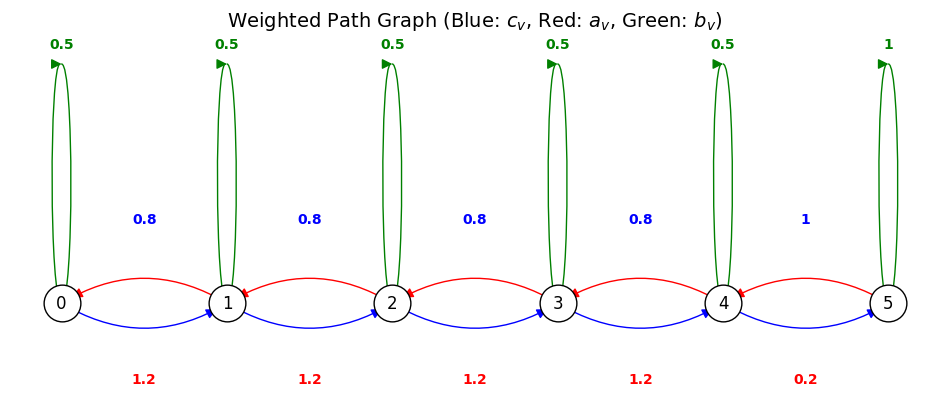

In [ ]:
# @title 有向辺上に重みを乗せる重み，セルフループ付きパスグラフを描画する
import matplotlib.pyplot as plt
import networkx as nx

def plot_weighted_path_graph(N, A, B, C):
    """
    N: 頂点数
    A: 右から(v+1 -> v)の重み [a_0, a_1, ..., a_{N-1}]
    B: セルフループ(v -> v)の重み [b_0, b_1, ..., b_{N-1}]
    C: 左から(v-1 -> v)の重み [c_0, c_1, ..., c_{N-1}]
    """
    G = nx.MultiDiGraph()
    pos = {i: (i, 0) for i in range(N)} # 一列に配置

    # グラフの構築とエッジの追加
    edge_labels = {}

    for v in range(N):
        # 1. セルフループ (b_v)
        G.add_edge(v, v, weight=B[v], type='self')

        # 2. 左からの辺 (v-1 -> v) : c_v
        if v > 0:
            G.add_edge(v-1, v, weight=C[v], type='forward')

        # 3. 右からの辺 (v+1 -> v) : a_v
        if v < N - 1:
            G.add_edge(v+1, v, weight=A[v], type='backward')

    fig, ax = plt.subplots(figsize=(12, 4))

    # ノードの描画
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='white', edgecolors='black', ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)

    # エッジの描画（種類ごとにカーブを変える）
    for u, v, data in G.edges(data=True):
        weight = data['weight']
        if data['type'] == 'forward': # 左から右へ（上側にカーブ）
            arc = "arc3,rad=0.3"
            color = "blue"
            label_pos = 0.3
        elif data['type'] == 'backward': # 右から左へ（下側にカーブ）
            arc = "arc3,rad=0.3"
            color = "red"
            label_pos = 0.3
        else: # セルフループ（真上に円を描く）
            arc = "arc3,rad=1.5"
            color = "green"
            label_pos = 0.5

        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], connectionstyle=arc,
                               edge_color=color, arrowsize=15, ax=ax)

        # 簡易的な重みラベルの表示（位置を微調整）
        x_mid = (pos[u][0] + pos[v][0]) / 2
        y_mid = (pos[u][1] + pos[v][1]) / 2

        offset = 0.05 if data['type'] == 'forward' else -0.05
        if data['type'] == 'self': offset = 0.16

        ax.text(x_mid, y_mid + offset, f"{weight}", color=color,
                fontsize=10, ha='center', fontweight='bold')

    plt.title("Weighted Path Graph (Blue: $c_v$, Red: $a_v$, Green: $b_v$)", fontsize=14)
    plt.axis('off')
    plt.show()

# --- 実行例 ---
N = 6
A = [1.2, 1.2, 1.2, 1.2, 0.2, 0] # 右からの重み
B = [0.5, 0.5, 0.5, 0.5, 0.5, 1] # セルフループ
C = [0.0, 0.8, 0.8, 0.8, 0.8, 1] # 左からの重み

plot_weighted_path_graph(N, A, B, C)

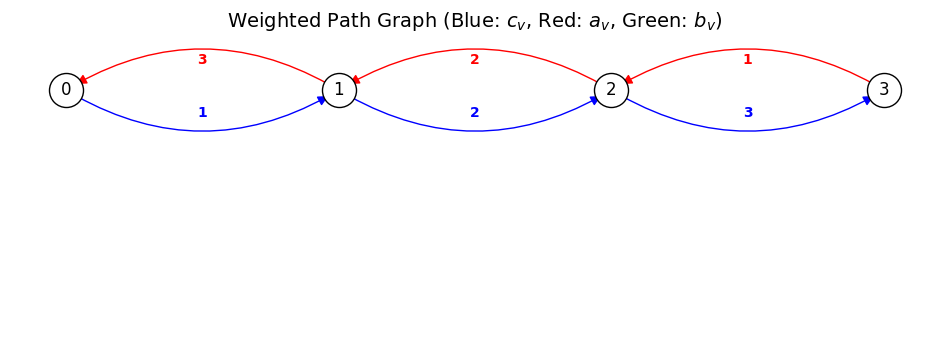

Pv_∞( 0) = 0.6493
Pv_∞( 1) = 0.3653
Pv_∞( 2) = 0.2914
Pv_∞( 3) = 0.3283


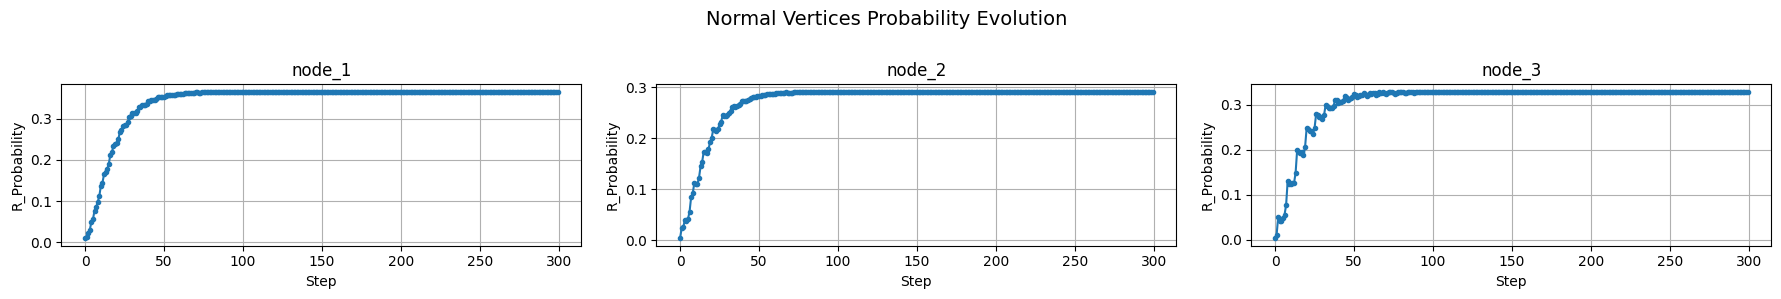

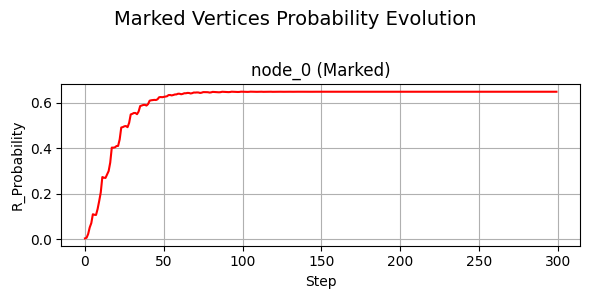

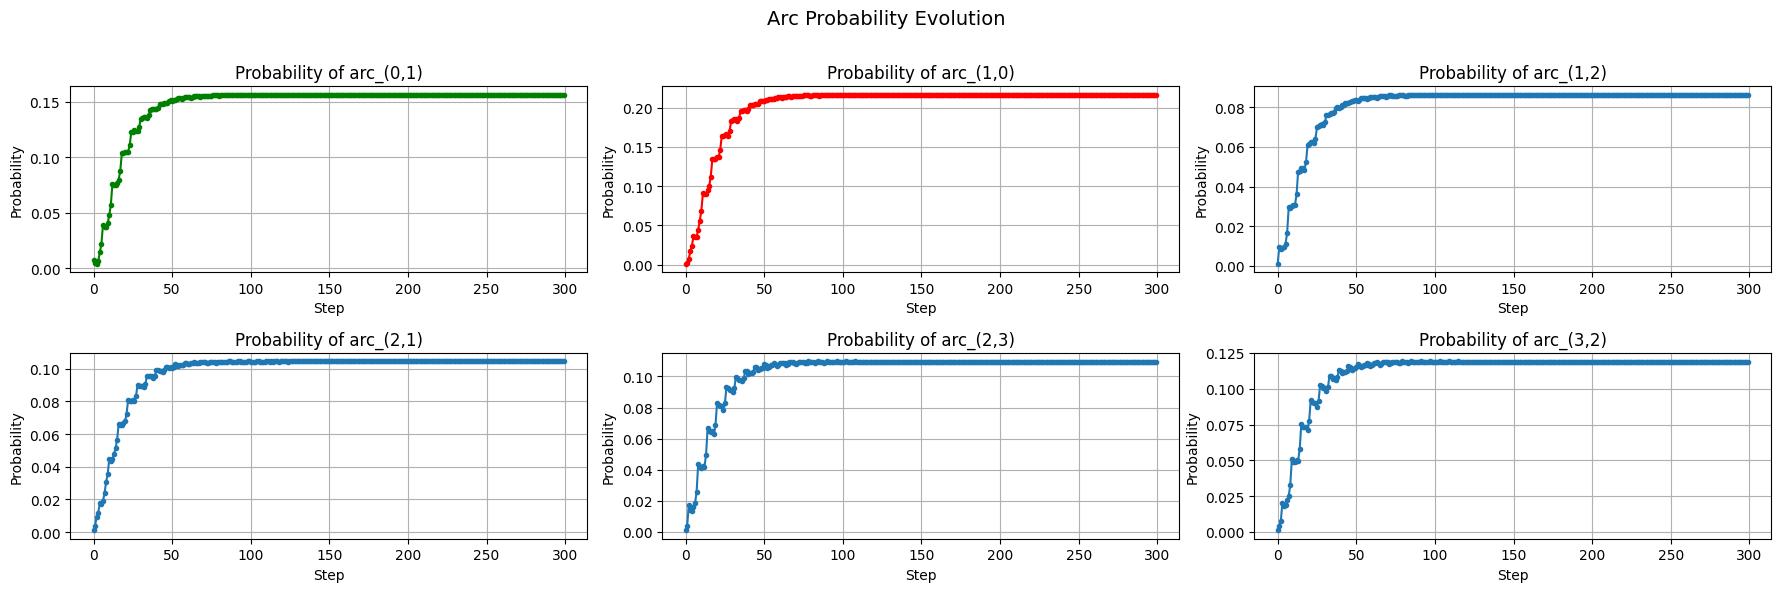

In [ ]:
# @title 実行コード: 重み付きパスグラフ上の量子ウォーク(Cube)
N = 4  # 頂点数

# 重みの設定 (長さNのリスト)
# a_v: 右から(v+1 -> v), b_v: セルフループ(v -> v), c_v: 左から(v-1 -> v)
A_weights = [3, 2, 1, 0]
B_weights = [0, 0, 0, 0]  # 例としてセルフループの重みを2.0に設定
C_weights = [0, 1, 2, 3]

A_weights[N-1] = 0.0  # 右端の頂点へ右から入る辺はない
C_weights[0] = 0.0    # 左端の頂点へ左から入る辺はない

marked = {0}  # 中央の頂点をマーク
external_arc = set(range(N))  # 全頂点に外部アーク(tail)を接続
epsilon = 0.05
N_origin_node=[1, 3, 3, 1]  #縮約時の各クラスの頂点数

# インスタンス生成 (新クラス)
q = WeightedPathQuantumWalkWithTails(N, A=A_weights, B=B_weights, C=C_weights)

#グラフの構造を確認
#print("------ グラフ構造の確認 ------")
q.plot_weighted_graph()

# 作用素の構築
q.set_conductances(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc)
q.build_shift()
q.build_coin(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc)

# 初期状態の設定
if epsilon == 0:#1/sqrt A で縮約グラフは設定できるか
    psi0 = np.ones(q.n_arcs, dtype=complex) / np.sqrt(q.n_arcs)
else:
    psi0 = np.zeros(q.n_arcs, dtype=complex)

q.set_initial_state(psi0)
q.set_rho(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc, N_origin_node=N_origin_node)

# 時間発展を実行
step = 300
z = complex(np.sqrt(7),np.sqrt(2))/3  # 例として z = i を設定

q.run(steps=step, epsilon=epsilon, z=z, N_origin_node=N_origin_node)

# 固有値の確認 (表示したい場合は True に)
# q.get_eigenpairs(vctBool=False)

# グラフと確率推移のプロット
q.plot_vertex_probs(steps=step, marked_vertices=marked)
q.plot_arc_probs(steps=step, marked_vertices=marked)

##Code

In [ ]:
# @title weight cal
import math

def make_weighted_path(a, b, c, D, N_last):

    degree = a + b + c

    #-----------------------
    # 頂点数
    #-----------------------
    N = [0]*(D+1)
    N[0] = 1
    N[1] = degree

    for i in range(2, D):
        # N_i = N_{i-1} c / a
        if (N[i-1]*c) % a != 0:
            raise ValueError(
                f"N[{i}] が整数になりません。 "
                f"{N[i-1]}×{c}/{a}"
            )
        N[i] = N[i-1]*c//a

    N[D] = N_last

    #-----------------------
    # 最後の重み
    #-----------------------
    if (N[D-1]*c) % N[D] != 0:
        raise ValueError(
            "最後の←重み a_D が整数になりません。"
        )

    a_last = N[D-1]*c//N[D]
    b_last = degree-a_last

    if b_last < 0:
        raise ValueError("最後のループ重みが負になります。")

    #-----------------------
    # 重み配列
    #-----------------------
    weight_right = [0]*(D+1)
    weight_loop = [0]*(D+1)
    weight_left = [0]*(D+1)

    weight_right[0] = degree

    for i in range(1,D):
        weight_right[i] = c
        weight_loop[i] = b
        weight_left[i] = a

    weight_right[D] = 0
    weight_loop[D] = b_last
    weight_left[D] = a_last

    return N,weight_right,weight_loop,weight_left

if __name__ == "__main__":
    a = 1  #a|cを満たすように
    b = 2
    c = 1
    D = 4
    N_last = 1

    N, w_right, w_loop, w_left = make_weighted_path(
    a, b, c, D, N_last
    )

    print("Layer size")
    print(N)

    print("\n→ weight")
    print(w_right)

    print("\nLoop weight")
    print(w_loop)

    print("\n← weight")
    print(w_left)

Layer size
[1, 4, 4, 4, 1]

→ weight
[4, 1, 1, 1, 0]

Loop weight
[0, 2, 2, 2, 0]

← weight
[0, 1, 1, 1, 4]


In [ ]:
# @title Johnson Graph Weight Calculation

def calc_c(i, n, k):
    return i ** 2

def calc_b(i, n, k):
    return i * (n - 2 * i)

def calc_a(i, n, k):
    return (k-i)*(n-k-i)

def calc_V(i, n, k):
    return math.comb(k,i) * math.comb(n-k,i)

def execute_process(n, k):
    # 1. d = min{n, n-k} の計算
    d = min(k, n - k)

    # 2. 0 から d まで（dを含む）ループを回して計算結果を配列に格納
    array_c_i = [calc_c(i, n, k) for i in range(d + 1)]
    array_b_i = [calc_b(i, n, k) for i in range(d + 1)]
    array_a_i = [calc_a(i, n, k) for i in range(d + 1)]
    array_V_i = [calc_V(i, n, k) for i in range(d + 1)]

    # 4つの配列をまとめて返す
    return array_a_i, array_b_i, array_c_i, array_V_i

if __name__ == "__main__":
    # 任意の n と k の値を設定
    n = 50
    k = 1

    # 処理の実行（それぞれの配列に分解して受け取る）
    res_a, res_b, res_c, res_V = execute_process(n, k)

    # 結果の出力
    print(f"n = {n}, k = {k}")
    print(f"d (min({k}, {n}-{k})): {min(k, n - k)}")
    print(f"頂点数 = {math.comb(n,k)}")
    print("-" * 30)
    print(f"N = {min(k, n-k)+1}")
    print(f"C_weights = {res_c}")
    print(f"B_weights = {res_b}")
    print(f"A_weights = {res_a}")
    print(f"N_origin_node = {res_V}")

n = 50, k = 1
d (min(1, 50-1)): 1
頂点数 = 50
------------------------------
N = 2
C_weights = [0, 1]
B_weights = [0, 48]
A_weights = [49, 0]
N_origin_node = [1, 49]


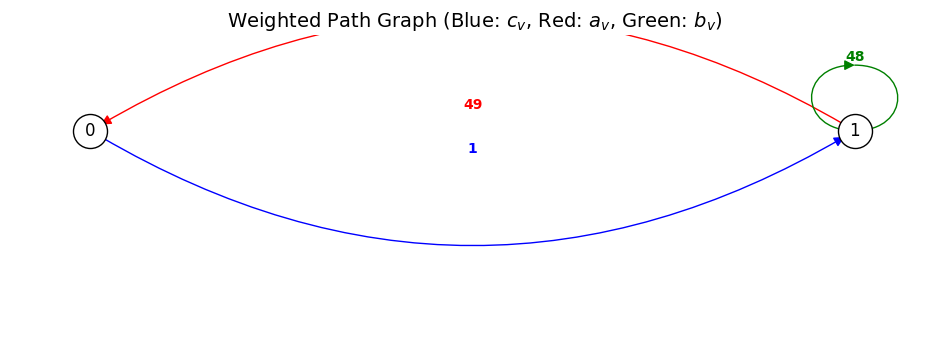

RPv_∞( 0) = 0.0204
RPv_∞( 1) = 0.0004
Pv_∞( 0) = 0.4947
Pv_∞( 1) = 0.0103
value: (-0.01225893250423471+0.6535312901561814j)
value: (-0.012258932504234765-0.6535312901561814j)
value: (0.9837015384778568+0j)


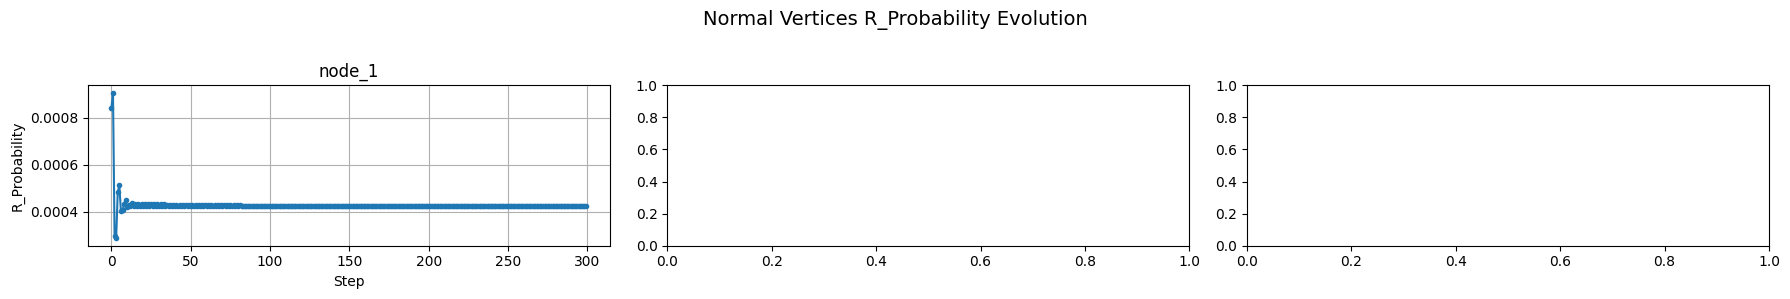

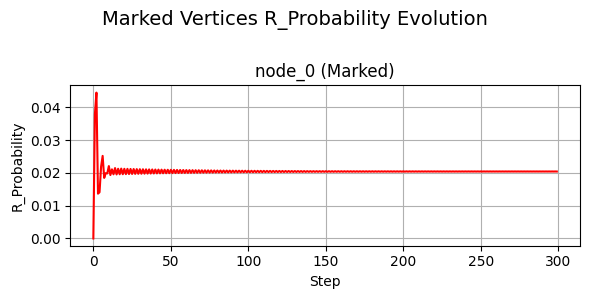

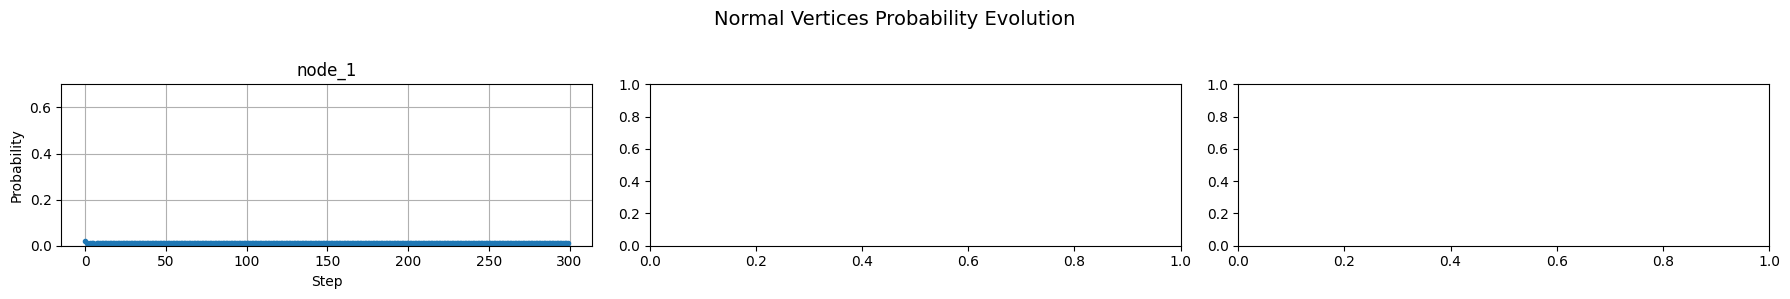

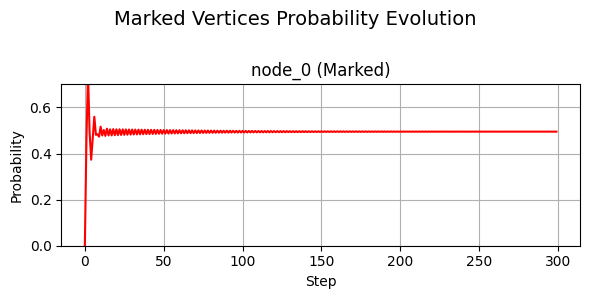

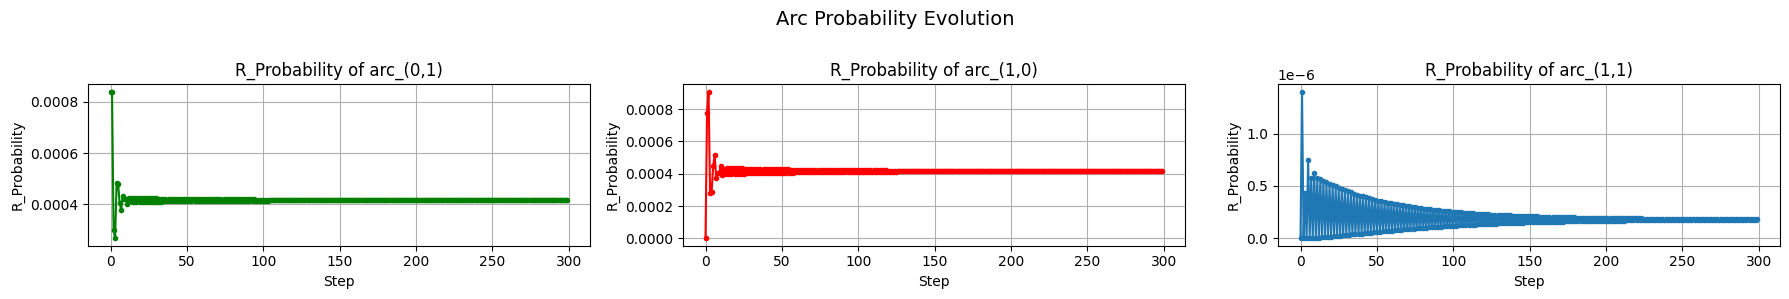

In [ ]:
# @title <font color ='red'>実行コード: 重み付きパスグラフ上の量子ウォーク</font>

# 重みの設定 (長さNのリスト)
# a_v: 右から(v+1 -> v), b_v: セルフループ(v -> v), c_v: 左から(v-1 -> v)
N = 2
C_weights = [0, 1]
B_weights = [0, 48]
A_weights = [49, 0]
N_origin_node = [1, 49]
A_weights[N-1] = 0.0  # 右端の頂点へ右から入る辺はない
C_weights[0] = 0.0    # 左端の頂点へ左から入る辺はない

marked = {0}  # 中央の頂点をマーク
external_arc = set(range(N))  # 全頂点に外部アーク(tail)を接続
external_arc = {0}
epsilon = 0.05

# インスタンス生成 (新クラス)
q = WeightedPathQuantumWalkWithTails(N, A=A_weights, B=B_weights, C=C_weights)

#グラフの構造を確認
#print("------ グラフ構造の確認 ------")
q.plot_weighted_graph()

# 作用素の構築
q.set_conductances(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc)
q.build_shift()
q.build_coin(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc)

# 初期状態の設定
if epsilon == 0:#1/sqrt A で縮約グラフは設定できるか
    psi0 = np.ones(q.n_arcs, dtype=complex) / np.sqrt(q.n_arcs)
else:
    psi0 = np.zeros(q.n_arcs, dtype=complex)

q.set_initial_state(psi0)
q.set_rho(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc, N_origin_node=N_origin_node)

# 時間発展を実行
step = 300
#z = complex(np.sqrt(7),np.sqrt(2))/3
z=-1

q.run(steps=step, epsilon=epsilon, z=z, N_origin_node=N_origin_node)

# 固有値の確認 (表示したい場合は True に)
q.get_eigenpairs(vctBool=False)

# グラフと確率推移のプロット
q.plot_vertex_probs(steps=step, marked_vertices=marked)
q.plot_v_probs(steps=step, marked_vertices=marked)
q.plot_arc_probs(steps=step, marked_vertices=marked)

Mounted at /content/drive
Pv_∞( 0) = 0.2497
Pv_∞( 1) = 0.0825
Pv_∞( 2) = 0.0092
Pv_∞( 3) = 0.0024
Pv_∞( 0) = 0.3987
Pv_∞( 1) = 0.1317
Pv_∞( 2) = 0.0147
Pv_∞( 3) = 0.0039
value: (0.816288871287907+0.37721240381974364j)
vector: [-4.20717959e-01+1.94416509e-01j -4.20717959e-01-1.94416509e-01j
 -2.44627455e-01-4.12643520e-02j -2.44627455e-01+4.12643520e-02j
 -1.55533212e-01-6.77174887e-02j -1.55533212e-01+6.77174887e-02j
  6.24302881e-01+3.24747638e-17j -3.44580332e-16-1.51427768e-31j]
value: (0.8162888712879062-0.37721240381974375j)
vector: [ 4.66536101e-01+0.00000000e+00j  4.66536101e-01+0.00000000e+00j
 -9.79720220e-03+2.62406401e-01j -9.79720220e-03-2.62406401e-01j
 -1.51265532e-01+1.02207449e-01j -1.51265532e-01-1.02207449e-01j
  6.00105554e-01+0.00000000e+00j -2.92373532e-16-6.45760650e-32j]
value: (0.12237913700938663+0.9375958366527587j)
vector: [ 0.08091172+1.86132870e-01j  0.08091172-1.86132870e-01j
 -0.26287909+2.11552622e-01j -0.26287909-2.11552622e-01j
 -0.31103755-1.44821346e

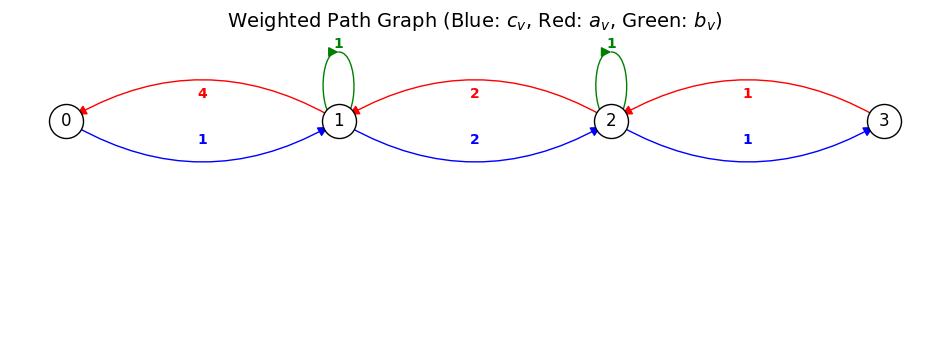

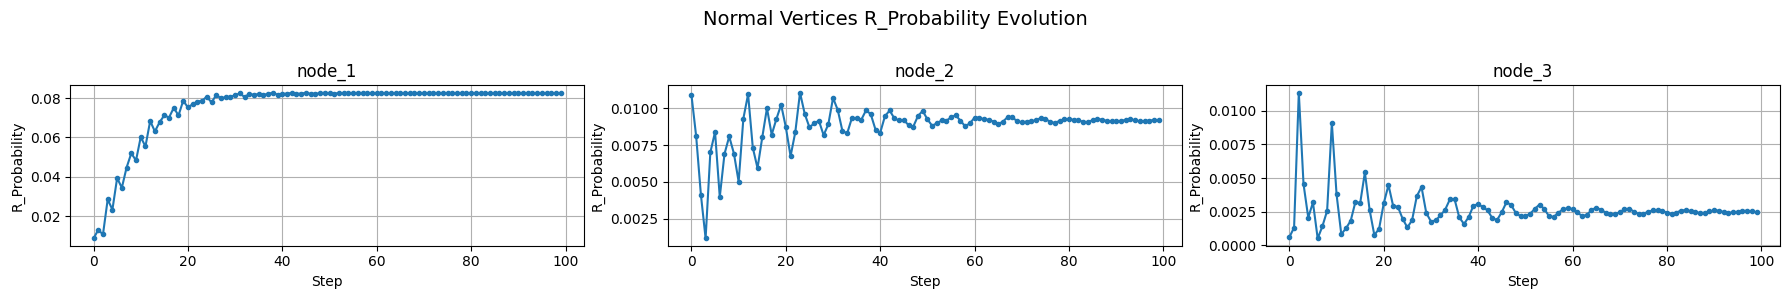

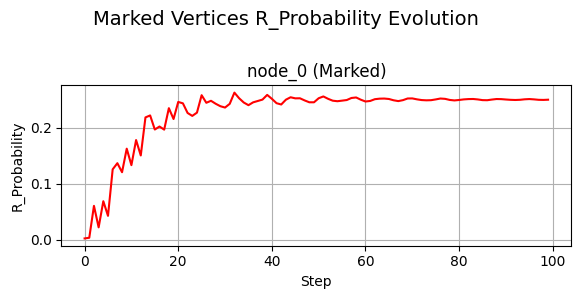

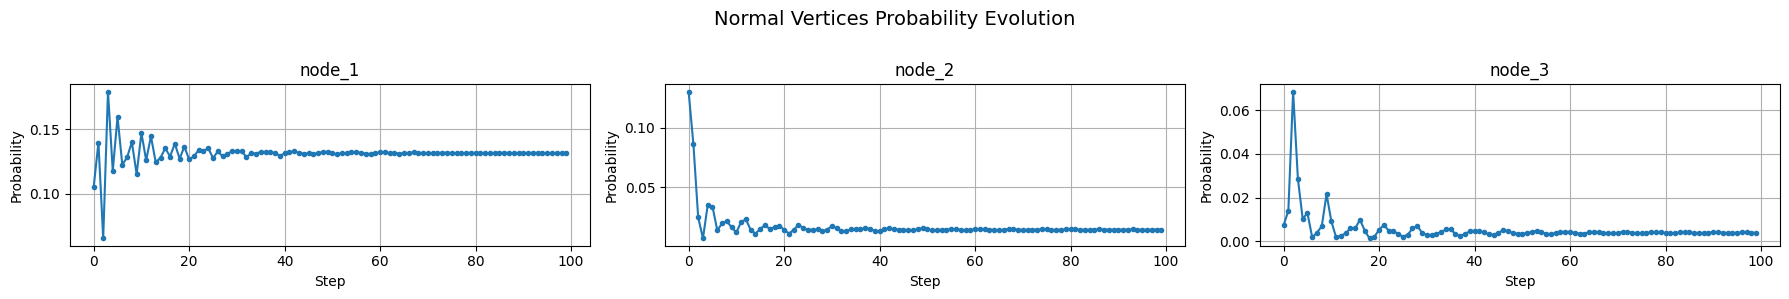

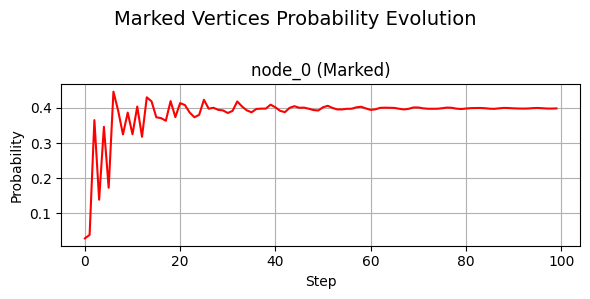

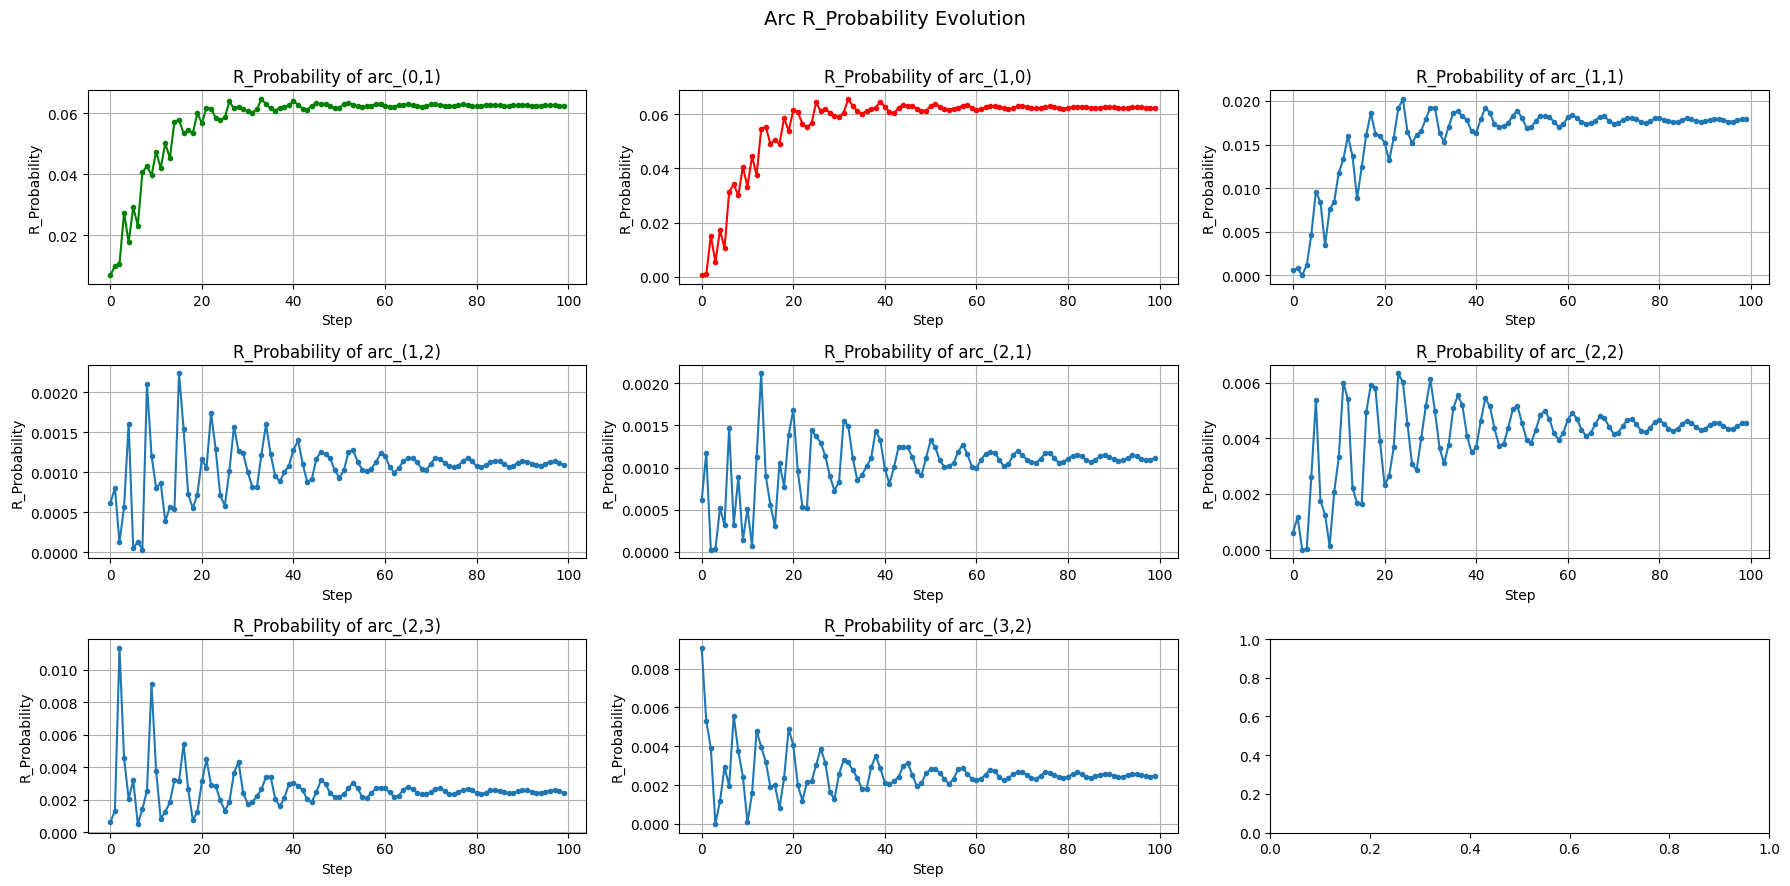

全てのグラフ（計 6 個）を一括保存しました：
/content/drive/MyDrive/QuantumWalk_Results/full_report_20260429_155046.png
ログ(設定・固有値・最終時刻の相対確率)を保存しました：
/content/drive/MyDrive/QuantumWalk_Results/log_20260429_155046.txt


In [ ]:
# @title 実行コード: 重み付きパスグラフ上の量子ウォーク(Googleマウント版)

import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from PIL import Image # 画像処理ライブラリ
from IPython.display import display # 画面表示用

# 1. Googleドライブをマウント
drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/QuantumWalk_Results/"
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# --- 設定とその実行 ---
N = 4
A_weights = [4, 2, 1, 1, 1, 0]
B_weights = [0, 1, 1, 0, 2, 0]
C_weights = [0, 1, 2, 1, 1, 4]
A_weights[N-1] = 0.0
C_weights[0] = 0.0

marked = {0}
external_arc = set(range(N))
epsilon = 0.05
N_origin_node = [1, 4, 4, 4, 4, 1]
step = 100
z = -1

q = WeightedPathQuantumWalkWithTailsMountVer(N, A=A_weights, B=B_weights, C=C_weights)
q.set_conductances(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc)
q.build_shift()
q.build_coin(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc)

psi0 = np.zeros(q.n_arcs, dtype=complex)
q.set_initial_state(psi0)
q.set_rho(marked_vertices=marked, epsilon=epsilon, external_arcs=external_arc, N_origin_node=N_origin_node)

# シミュレーション実行
q.run(steps=step, epsilon=epsilon, z=z, N_origin_node=N_origin_node)

# 固有値の確認 (固有ベクトルを表示したい場合は True に)
q.get_eigenpairs(vctBool=True)

# --- 保存処理1: グラフのpng保存 ---
# --- 画像の収集 ---
print("画像を生成中...")
all_figs = []

# 各メソッドから Figure を受け取る
all_figs.append(q.plot_weighted_graph())     # 構造図
all_figs.extend(q.plot_vertex_probs(step, marked)) # 頂点確率 (リストが返るため extend)
all_figs.extend(q.plot_v_probs(step, marked))   # 確率 (リストが返るため extend)
all_figs.append(q.plot_arc_probs(step, marked))   # アーク確率

# --- 画像の保存と結合処理 ---
save_dir = "/content/drive/MyDrive/QuantumWalk_Results/"
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

temp_files = []
for i, fig in enumerate(all_figs):
    display(fig) # (colab)表示
    #一時保存
    temp_name = f"temp_{i}.png"
    fig.savefig(temp_name, bbox_inches='tight', pad_inches=0.1)
    temp_files.append(temp_name)
    plt.close(fig) # メモリ解放

# Pillowで結合
images = [Image.open(f) for f in temp_files]
total_width = max(img.width for img in images)
total_height = sum(img.height for img in images)

combined_img = Image.new('RGB', (total_width, total_height), (255, 255, 255))

current_y = 0
for img in images:
    combined_img.paste(img, (0, current_y))
    current_y += img.height

# 最終保存
final_filename = f"{save_dir}full_report_{timestamp}.png"
combined_img.save(final_filename)

# 一時ファイルの削除
for f in temp_files:
    os.remove(f)

print(f"全てのグラフ（計 {len(all_figs)} 個）を一括保存しました：\n{final_filename}")

# --- 保存処理2: ログ（設定値と固有値）のテキスト保存 ---
log_file = f"{save_dir}log_{timestamp}.txt"
with open(log_file, 'w', encoding='utf-8') as f:
    f.write(f"=== Quantum Walk Simulation Log ===\n")
    f.write(f"Date: {timestamp}\n")
    f.write(f"Parameters: N={N}, epsilon={epsilon}, z={z}\n")
    f.write(f"A: {A_weights}\nB: {B_weights}\nC: {C_weights}\n")
    f.write(f"Marked: {marked}, N_origin: {N_origin_node}\n\n")

    f.write("--- Final Relative Probabilities ---\n")
    for v, p in q.history[-1].items():
        f.write(f"Node {v}: {p:.6f}\n")

    f.write("--- Final Probabilities ---\n")
    for u, r in q.history_prob[-1].items():
        f.write(f"Node {u}: {r:.6f}\n")

    f.write("\n--- Eigenvalues of U ---\n")
    vals, vcts = np.linalg.eig(q.U)
    for val in vals:
        f.write(f"{val}\n")
    """
    f.write("\n--- Eigenvectors of U ---\n")
    for vct in vcts:
        f.write(f"{vct}\n")
    """
print(f"ログ(設定・固有値・最終時刻の相対確率)を保存しました：\n{log_file}")

今後やること

* いろんなグラフに対して行う
* GitHubにUPする

変更考慮点

* 保存を毎回フォルダーにして保存する(dirctを時刻付きに変更することで可能)
* ファイル名を頭に時刻にする(あんま推奨されてない,PHPで使えない)
*